# Modelo Random Forest

## Paso 1: Importación de Librerías y Carga de Datos

Cargamos las herramientas necesarias y los datos escalados del pipeline.
Se aplica SMOTE **dentro de cada fold** de la validación cruzada para evitar data leakage.


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, accuracy_score, classification_report, precision_score, recall_score
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

# Cargamos los datos del pipeline (ya sin variables leaky)
X_train = pd.read_csv('../data/processed/X_train_scaled.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
X_test  = pd.read_csv('../data/processed/X_test_scaled.csv')
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Cargamos la configuración compartida de CV
cv_config = joblib.load('../models/cv_config.pkl')
skf = StratifiedKFold(**cv_config)

print(f'X_train: {X_train.shape}  |  y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   |  y_test:  {y_test.shape}')
print()
print('Distribución en train (sin SMOTE — distribución real):')
print((y_train.value_counts(normalize=True) * 100).round(1))
print()
print('Distribución en test:')
print((y_test.value_counts(normalize=True) * 100).round(1))


X_train: (7259, 21)  |  y_train: (7259,)
X_test:  (1815, 21)   |  y_test:  (1815,)

Distribución en train (sin SMOTE — distribución real):
target_tipo_ui
none      53.5
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64

Distribución en test:
target_tipo_ui
none      53.6
mixed     18.1
stress    17.5
urge      10.9
Name: proportion, dtype: float64


## Nota sobre variables leaky

Las variables `ui_esfuerzo_presente` y `ui_urgencia_presente` ya fueron
eliminadas en el pipeline de preprocesamiento por presentar data leakage
(Cramér's V = 1.0 con el target).


## Paso 2: Modelo Base (Baseline) con CV honesta

Usamos `ImbPipeline` para que el SMOTE se aplique **dentro de cada fold**
de la validación cruzada.

**Flujo dentro de cada fold:**
1. Datos de train del fold (datos reales) → SMOTE → datos balanceados
2. Random Forest entrena con datos balanceados
3. Evalúa sobre el fold de validación (datos reales, sin sintéticos)

Así las métricas de CV reflejan el rendimiento real del modelo.


In [4]:
# Pipeline: SMOTE + Random Forest (SMOTE se aplica solo al train de cada fold)
pipeline_baseline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

cv_results = cross_validate(
    pipeline_baseline,
    X_train, y_train,
    cv=skf,
    scoring={
        'accuracy': 'accuracy',
        'f1_macro': 'f1_macro',
        'f1_weighted': 'f1_weighted'
    },
    n_jobs=-1
)

baseline_f1_macro = cv_results['test_f1_macro'].mean()
baseline_accuracy = cv_results['test_accuracy'].mean()

print('=' * 55)
print('BASELINE — Validación cruzada 5-fold (CV honesta)')
print('=' * 55)
print(f'Accuracy:    {baseline_accuracy:.4f} +/- {cv_results["test_accuracy"].std():.4f}')
print(f'F1-macro:    {baseline_f1_macro:.4f} +/- {cv_results["test_f1_macro"].std():.4f}')
print(f'F1-weighted: {cv_results["test_f1_weighted"].mean():.4f} +/- {cv_results["test_f1_weighted"].std():.4f}')


BASELINE — Validación cruzada 5-fold (CV honesta)
Accuracy:    0.6196 +/- 0.0073
F1-macro:    0.4740 +/- 0.0135
F1-weighted: 0.6053 +/- 0.0099


## Paso 3: Optimización con Optuna


In [5]:
def rf_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 5, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
    }

    pipeline = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('rf', RandomForestClassifier(
            **params,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1
        ))
    ])

    cv = cross_validate(pipeline, X_train, y_train, cv=skf,
                        scoring='f1_macro', return_train_score=True)
    gap = cv['train_score'].mean() - cv['test_score'].mean()
    if gap > 0.05:
        return -1.0
    return cv['test_score'].mean()

# Creamos el estudio Optuna para maximizar el F1-Macro
study = optuna.create_study(direction='maximize', study_name='RF_Optimization')
study.optimize(rf_objective, n_trials=30)

print(f'Mejor F1-Macro CV: {study.best_value:.4f}')
print('Mejores parámetros:', study.best_params)


Mejor F1-Macro CV: 0.4881
Mejores parámetros: {'n_estimators': 202, 'max_depth': 5, 'min_samples_split': 13, 'max_features': 'log2'}


## Paso 4: Comparación Baseline vs Modelo Afinado


In [6]:
# Aplicamos SMOTE al train completo para entrenar los modelos finales
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f'Train con SMOTE: {X_train_sm.shape}')

# Baseline
rf_baseline = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_baseline.fit(X_train_sm, y_train_sm)
y_pred_baseline = rf_baseline.predict(X_test)
baseline_test_f1 = f1_score(y_test, y_pred_baseline, average='macro')

# Modelo Tuneado con los parámetros de Optuna
best_params = study.best_params
rf_tuned = RandomForestClassifier(
    **best_params,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_tuned.fit(X_train_sm, y_train_sm)
y_pred_tuned = rf_tuned.predict(X_test)
tuned_test_f1 = f1_score(y_test, y_pred_tuned, average='macro')

print()
print('=== RENDIMIENTO EN TEST (datos reales) ===')
print(f'Baseline F1-Macro:     {baseline_test_f1:.4f}')
print(f'Tuneado F1-Macro:      {tuned_test_f1:.4f}')
print(f'Diferencia:            {tuned_test_f1 - baseline_test_f1:.4f}')


Train con SMOTE: (15540, 21)

=== RENDIMIENTO EN TEST (datos reales) ===
Baseline F1-Macro:     0.4602
Tuneado F1-Macro:      0.4800
Diferencia:            0.0199


## Paso 5: Importancia de Variables (Feature Importances)


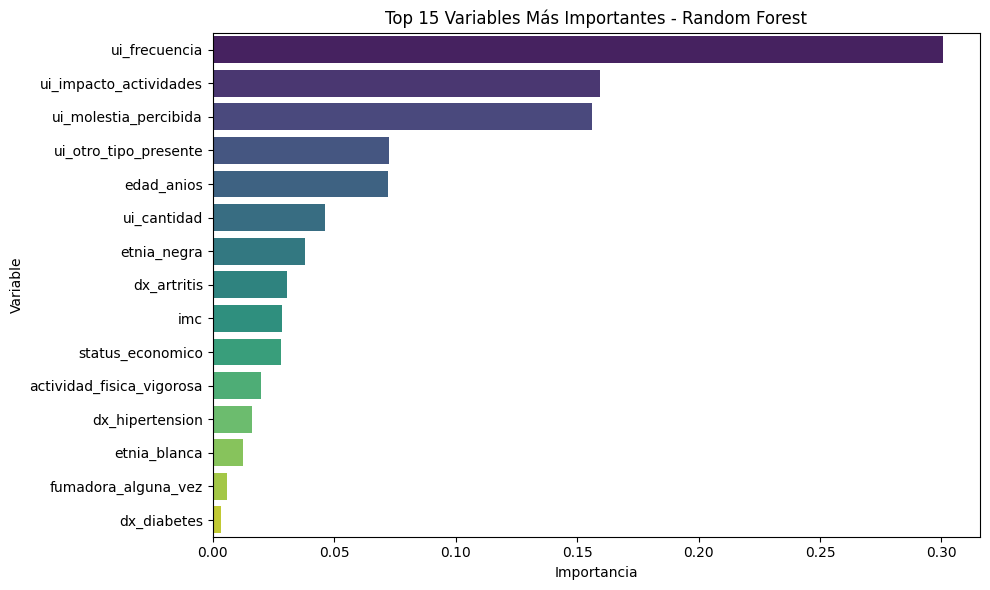

In [7]:
importances = rf_tuned.feature_importances_
feature_names = X_train.columns

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Top 15 Variables Más Importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()


## Paso 6: Métricas Finales


In [8]:
# Métricas globales
acc = accuracy_score(y_test, y_pred_tuned)
f1_mac = f1_score(y_test, y_pred_tuned, average='macro')
prec_mac = precision_score(y_test, y_pred_tuned, average='macro')
rec_mac = recall_score(y_test, y_pred_tuned, average='macro')

print('=== MÉTRICAS GLOBALES (Modelo Tuneado) ===')
print(f'Accuracy:        {acc:.4f}')
print(f'F1-Macro:        {f1_mac:.4f}')
print(f'Precision-Macro: {prec_mac:.4f}')
print(f'Recall-Macro:    {rec_mac:.4f}')

print()
print('=== REPORTE POR CLASE ===')
print(classification_report(y_test, y_pred_tuned))

# Overfitting check
y_pred_train = rf_tuned.predict(X_train_sm)
f1_train = f1_score(y_train_sm, y_pred_train, average='macro')
overfit = f1_train - f1_mac
print(f'F1-Macro Train: {f1_train:.4f}')
print(f'F1-Macro Test:  {f1_mac:.4f}')
print(f'Diferencia:     {overfit:.4f} ({overfit*100:.2f}%)')


=== MÉTRICAS GLOBALES (Modelo Tuneado) ===
Accuracy:        0.6176
F1-Macro:        0.4800
Precision-Macro: 0.4894
Recall-Macro:    0.4754

=== REPORTE POR CLASE ===
              precision    recall  f1-score   support

       mixed       0.53      0.52      0.53       328
        none       0.75      0.82      0.78       972
      stress       0.39      0.35      0.37       317
        urge       0.29      0.21      0.24       198

    accuracy                           0.62      1815
   macro avg       0.49      0.48      0.48      1815
weighted avg       0.60      0.62      0.61      1815

F1-Macro Train: 0.5602
F1-Macro Test:  0.4800
Diferencia:     0.0802 (8.02%)


## Paso 7: Guardar Modelo


In [9]:
os.makedirs('../models', exist_ok=True)
joblib.dump(rf_tuned, '../models/random_forest.pkl')
print('Modelo guardado en models/random_forest.pkl')


Modelo guardado en models/random_forest.pkl
